# Feature Space and Classification Lab
The objectives of this lab are for you to ...
1. Conceptualize the transition from the image space to feature space
1. Visualize the feature space and to
1. Understand manifolds and discriminability in feature space
1. Experiment on this feature space with simple classifiers 
1. Assess the performance of the classifiers for visual recognition

## Libraries, data set, sanity check

In [1]:
import sys
print(sys.executable)

import torch
print("torch:", torch.__version__)

import cv2
print("cv2:", cv2.__version__)


c:\Users\jgooh\anaconda3\envs\cs4330\python.exe
torch: 2.2.2
cv2: 4.10.0


In [2]:
# one-time prep work
# set matplotlib to render in this window, with the specified figure size
%matplotlib inline
import random
import numpy as np
import cv2 as cv
print(f"Your OpenCV Version is {cv.__version__} - please review the documentation: "
      f"https://docs.opencv.org/{cv.__version__}/")
import matplotlib.pyplot as plt

Your OpenCV Version is 4.10.0 - please review the documentation: https://docs.opencv.org/4.10.0/


The code and data for this this lab come from various key sources, including [scikit-learn](https://scikit-learn.org/stable/index.html) and OpenCV. Please spend 10 minutes to look through the [OpenCV Documentation](https://docs.opencv.org/4.9.0/) (select the version that matches what you have installed) to get an overview of the available functionality.

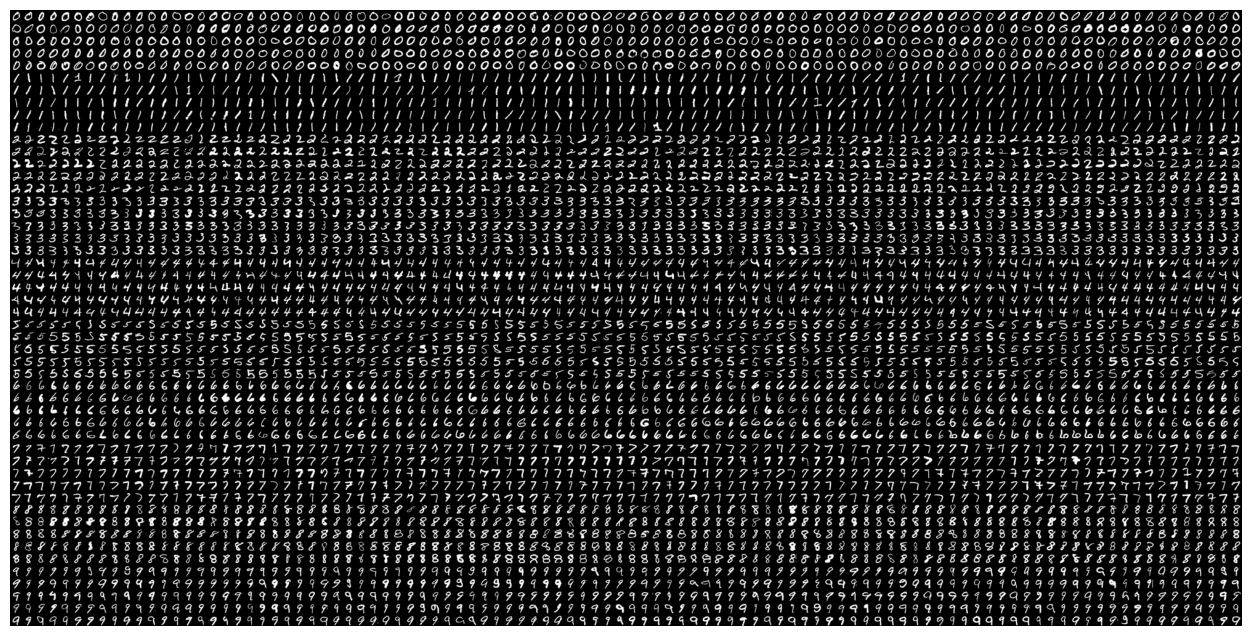

In [3]:
# Load digits.png: this single large image of 50x100 digits, each 20x20 in size, 
# used to be in OpenCV/data. You can find it on the web, search for "opencv digits.png".
img = cv.imread('digits.png')
plt.figure(figsize=(16, 8));
plt.gray()
plt.imshow(img), plt.axis('off'), plt.show();

# if you cannot find this image, you can alternatively work with a built-in dataset,
# but you will need to convert the cell sizing, train and test sets, etc.
# See here for usage info: https://scikit-learn.org/stable/auto_examples/manifold/plot_lle_digits.html
#from sklearn.datasets import load_digits
#digits = load_digits()
#print(digits.data.shape) # 10 classes, about 180 images/class, 8x8 images

gray = cv.cvtColor(img,cv.COLOR_BGR2GRAY)
# Now we split the image to 5000 cells, each 20x20 size
cells = [np.hsplit(row,100) for row in np.vsplit(gray,50)]
# Make it into a Numpy array: its size will be (50,100,20,20).
# The first 5 rows are of 0s, the next of 1s, and so on.
x = np.array(cells)

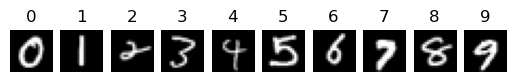

In [4]:
# Prepare the training data and test data including labels
train = x[:,:50].reshape(-1,400).astype(np.float32) # Size = (2500,400) with 400=20x20 pixels
test = x[:,50:100].reshape(-1,400).astype(np.float32) # Size = (2500,400)
# Create labels for train and test data
k = np.arange(10)
train_labels = np.repeat(k,250)[:,np.newaxis]
test_labels = train_labels.copy()

# Sanity check: render random digits and their labels. There are 250 of each class.
for i in np.arange(10):
    plt.subplot(1, 10, i+1)
    r = random.randint(i*250,(i+1)*250-1)
    ri = train[r,:].reshape(20, 20)
    plt.imshow(ri), plt.title(train_labels[r,0]), plt.axis('off')
plt.show();

## Neural Networks

In [5]:
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

In [6]:
print("type(train):", type(train))
try:
    print("train dtype:", getattr(train, "dtype", None))
    print("train shape:", getattr(train, "shape", None))
except Exception as e:
    print("error inspecting train:", e)

print("first element type:", type(train[0]) if hasattr(train, "__len__") else None)
print("train[0]:", train[0] if hasattr(train, "__len__") else None)


type(train): <class 'numpy.ndarray'>
train dtype: float32
train shape: (2500, 400)
first element type: <class 'numpy.ndarray'>
train[0]: [  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0.   0.   0.   0.   0.   9.  33.   9.   0.   0.
   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
  41. 177. 249. 178.  29.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0.  33. 198. 255. 240. 255. 107.   0.   0.   0.
   0.   0.   0.   0.   0.   0.   0.   0.   0.   1.  70. 199. 255. 255.
 197. 154. 253.  98.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.  45. 238. 255. 205. 224. 222.  83. 224. 128.   0.   0.   0.   0.
   0.   0.   0.   0.   0.   0.  25. 202. 255. 193.  40.  99.  54.   0.
 190. 197.  16.   0.   0.   0.   0.   0.   0.   0.   0.  20. 163. 246.
 152.  72. 

In [7]:
# Convert numpy arrays to PyTorch tensors
train_tensor = torch.tensor(train)
train_labels_tensor = torch.tensor(train_labels).squeeze().long()
test_tensor = torch.tensor(test)
test_labels_tensor  = torch.tensor(test_labels).squeeze().long()

# Create datasets
train_dataset = TensorDataset(train_tensor, train_labels_tensor)
test_dataset = TensorDataset(test_tensor, test_labels_tensor)

# Create data loaders
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Print dataset sizes
print(f"Training set size: {len(train_dataset)} samples")
print(f"Test set size: {len(test_dataset)} samples")
print(f"Number of batches in train_loader: {len(train_loader)}")
print(f"Number of batches in test_loader: {len(test_loader)}")

# Show an example batch
sample_batch = next(iter(train_loader))
print(f"\nSample batch - Features shape: {sample_batch[0].shape}, Labels shape: {sample_batch[1].shape}")

Training set size: 2500 samples
Test set size: 2500 samples
Number of batches in train_loader: 40
Number of batches in test_loader: 40

Sample batch - Features shape: torch.Size([64, 400]), Labels shape: torch.Size([64])


In [8]:
# Get cpu or gpu device for training.
device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Using {device} device")

# Define model
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(20*20, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

model = NeuralNetwork().to(device)
print(model)

Using cpu device
NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=400, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)


In [9]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)

def train_epoch(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        # Compute prediction error
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if batch % 100 == 0:
            loss, current = loss.item(), batch * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

In [10]:
epochs = 100
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train_epoch(train_loader, model, loss_fn, optimizer)
    test(test_loader, model, loss_fn)
print("Done!")

Epoch 1
-------------------------------
loss: 19.182579  [    0/ 2500]
Test Error: 
 Accuracy: 65.9%, Avg loss: 1.222933 

Epoch 2
-------------------------------
loss: 1.117409  [    0/ 2500]
Test Error: 
 Accuracy: 64.5%, Avg loss: 1.396089 

Epoch 3
-------------------------------
loss: 1.050106  [    0/ 2500]
Test Error: 
 Accuracy: 72.2%, Avg loss: 1.008489 

Epoch 4
-------------------------------
loss: 0.694618  [    0/ 2500]
Test Error: 
 Accuracy: 79.4%, Avg loss: 0.785004 

Epoch 5
-------------------------------
loss: 0.521854  [    0/ 2500]
Test Error: 
 Accuracy: 81.3%, Avg loss: 0.710710 

Epoch 6
-------------------------------
loss: 0.537980  [    0/ 2500]
Test Error: 
 Accuracy: 80.1%, Avg loss: 0.743495 

Epoch 7
-------------------------------
loss: 0.340361  [    0/ 2500]
Test Error: 
 Accuracy: 81.8%, Avg loss: 0.702622 

Epoch 8
-------------------------------
loss: 0.471806  [    0/ 2500]
Test Error: 
 Accuracy: 85.9%, Avg loss: 0.583508 

Epoch 9
---------------

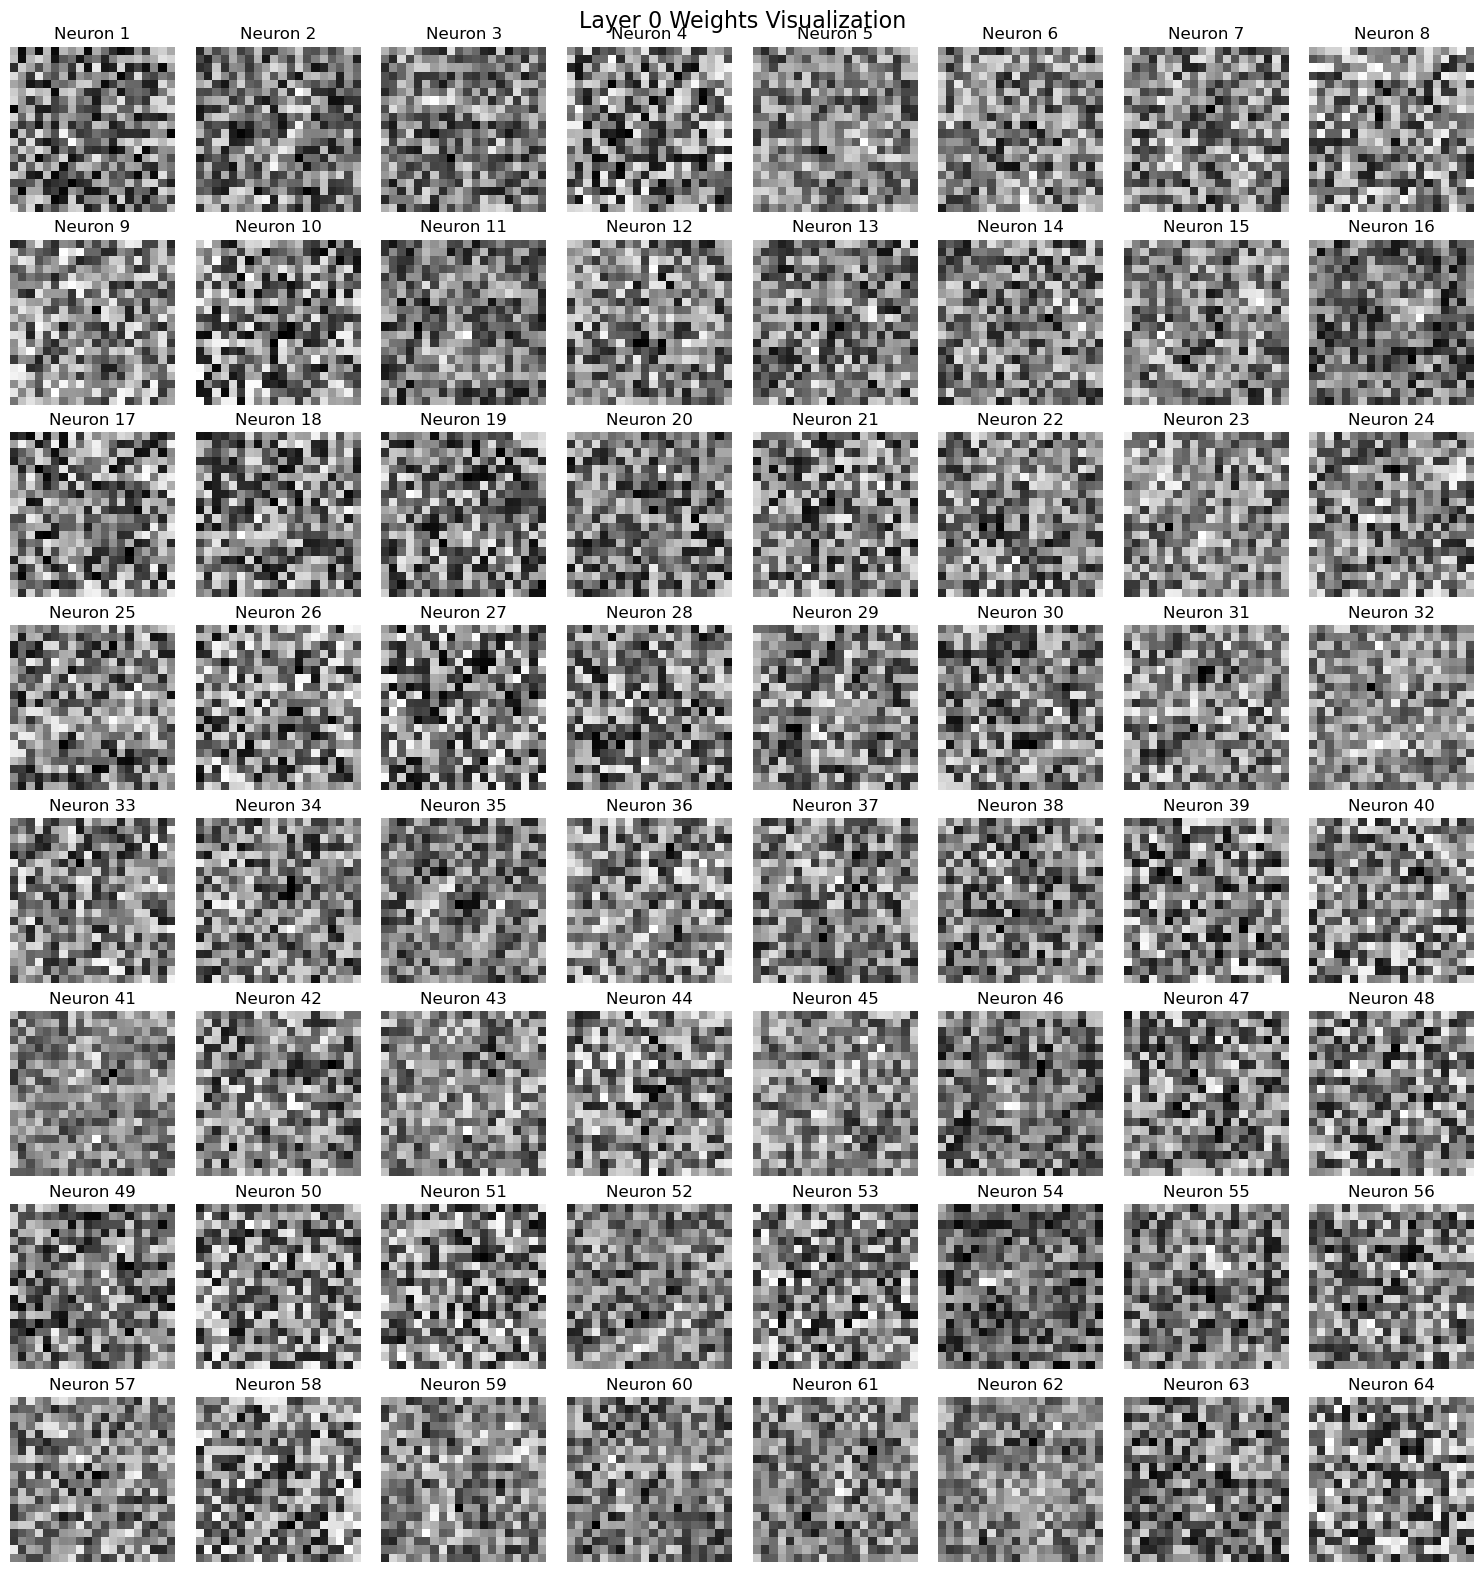

Visualizing Layer 0 of shape (64, 400)
Number of neurons: 64
Input features per neuron: 400


In [11]:
def visualize_layer_weights(model, layer_num=0):
    """
    Visualize the weights of a specified layer in the neural network.
    
    Args:
        model: The PyTorch model
        layer_num: Index of the layer to visualize (0 for first hidden layer, 1 for second, etc.)
    """
    linear_layers = [module for module in model.modules() 
                    if isinstance(module, torch.nn.Linear)]
    if layer_num < 0 or layer_num >= len(linear_layers):
        print(f"Error: Layer number must be between 0 and {len(linear_layers)-1}")
        return
    with torch.no_grad():
        weights = linear_layers[layer_num].weight.cpu().numpy()
    
    # Determine if we can reshape to square (only for input layer or layers with square input)
    input_size = weights.shape[1]
    img_size = int(np.sqrt(input_size))
    can_reshape = (img_size * img_size == input_size)
    
    # Create a figure to display the weights
    ncols = 8
    nrows = (weights.shape[0] + ncols - 1) // ncols    
    plt.figure(figsize=(15, 2 * nrows))
    plt.suptitle(f'Layer {layer_num} Weights Visualization', fontsize=16)
    
    for i in range(min(weights.shape[0], nrows * ncols)):  # for each subplot
        plt.subplot(nrows, ncols, i + 1)        
        if can_reshape:
            weight_img = weights[i].reshape(img_size, img_size)
        else:
            weight_img = weights[i]
            
        #weight_img = (weight_img - weight_img.min()) / (weight_img.max() - weight_img.min() + 1e-6)        
        if can_reshape:
            plt.imshow(weight_img, cmap='gray')
        else:
            # For non-square layers, plot as a 1D array
            plt.plot(weight_img)
            plt.axis('off')
            
        plt.axis('off')
        plt.title(f'Neuron {i+1}')
    
    plt.tight_layout()
    plt.show()
    
    # Print layer information
    print(f"Visualizing Layer {layer_num} of shape {weights.shape}")
    print(f"Number of neurons: {weights.shape[0]}")
    print(f"Input features per neuron: {weights.shape[1]}")

visualize_layer_weights(model, layer_num=0) # change from 0..2 to visualize each of the 3 layers

## Activations
The neural network we have trained can now transform the input image into successive "activations" - the result of the linear neuron operation and the activation function, and the output at each layer. Let us visualize the image-dependent activations - not to be confused with visualizations of the (fixed) weights. Please read up about neural networks if you are unsure about activations or weights. 

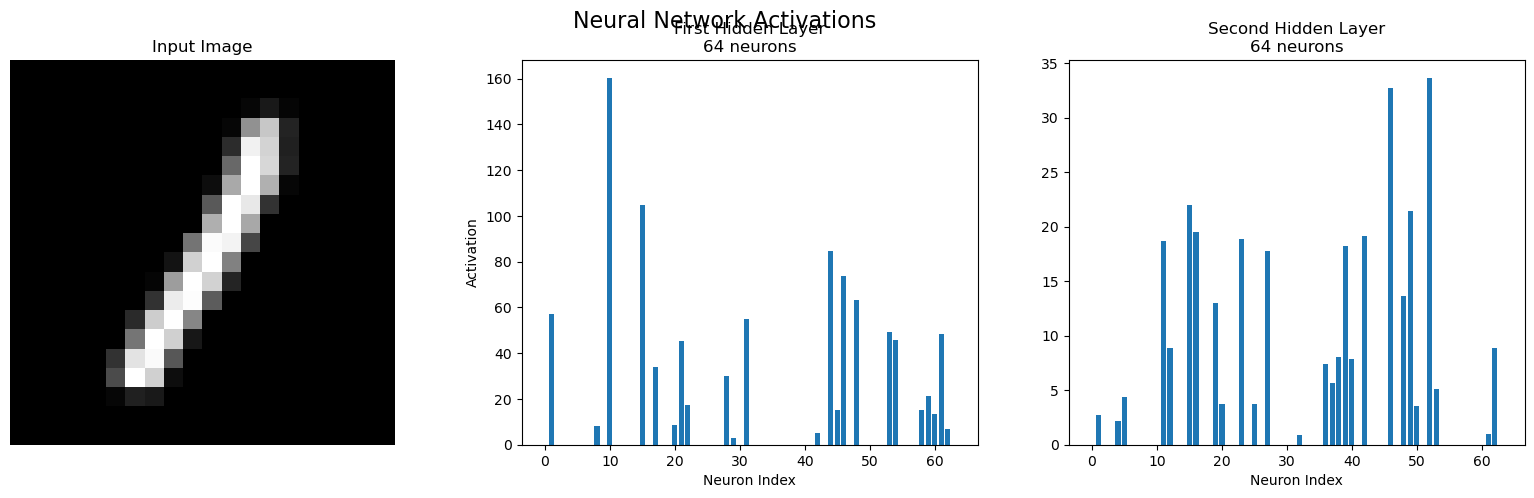

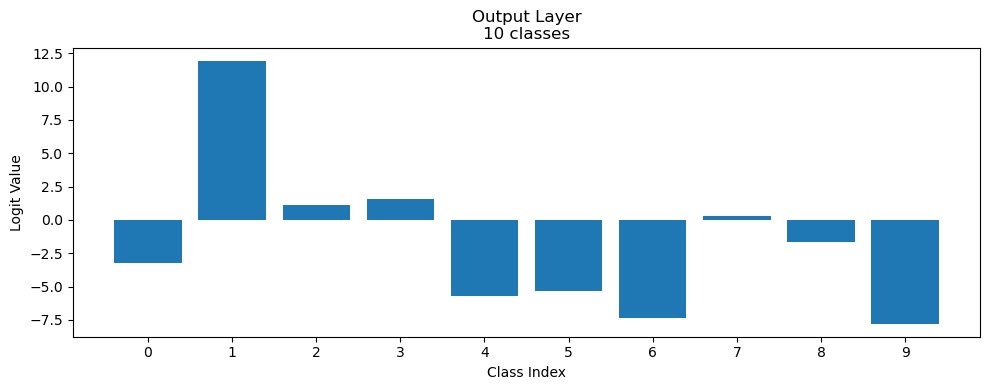

Predicted class: 1
Output logits: [-3.26 11.93  1.09  1.54 -5.74 -5.36 -7.32  0.32 -1.65 -7.78]


In [12]:
def visualize_activations(model, input_image):
    """
    Visualize the activations at each layer of the network for a given input image.
    
    Args:
        model: The PyTorch model
        input_image: A single input image (numpy array or tensor) of shape (1, 20, 20) or (400,)
    """
    if isinstance(input_image, np.ndarray):
        input_image = torch.from_numpy(input_image).float()
    
    # Ensure the input is 1D (flattened) and add batch dimension
    if input_image.dim() == 2:
        input_image = input_image.view(-1)
    if input_image.dim() == 1:
        input_image = input_image.unsqueeze(0)    
    input_image = input_image.to(device)
    
    # Dictionary and hook function to store activations
    activations = {}
    def get_activation(name):
        def hook(model, input, output):
            activations[name] = output.detach()
        return hook
    
    # Register hooks for each layer
    hooks = []
    for i, layer in enumerate(model.linear_relu_stack):
        if isinstance(layer, nn.Linear) or isinstance(layer, nn.ReLU):
            hooks.append(layer.register_forward_hook(get_activation(f'layer_{i}')))
    
    # Forward pass
    with torch.no_grad():
        model.eval()
        output = model(input_image)
    
    # Remove hooks
    for hook in hooks:
        hook.remove()
    
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    fig.suptitle('Neural Network Activations', fontsize=16)
    
    if input_image.shape[1] == 400:  # If input is flattened
        img = input_image[0].cpu().numpy().reshape(20, 20)
    else:
        img = input_image[0].cpu().numpy()
    axes[0].imshow(img, cmap='gray')
    axes[0].set_title('Input Image')
    axes[0].axis('off')
    
    # Plot first hidden layer activations (after first Linear + ReLU)
    if 'layer_0' in activations and 'layer_1' in activations:
        act = activations['layer_1'].cpu().numpy()[0]  # Get first sample in batch
        axes[1].bar(range(len(act)), act)
        axes[1].set_title(f'First Hidden Layer\n{len(act)} neurons')
        axes[1].set_xlabel('Neuron Index')
        axes[1].set_ylabel('Activation')
    
    # Plot second hidden layer activations (after second Linear + ReLU)
    if 'layer_2' in activations and 'layer_3' in activations:
        act = activations['layer_3'].cpu().numpy()[0]
        axes[2].bar(range(len(act)), act)
        axes[2].set_title(f'Second Hidden Layer\n{len(act)} neurons')
        axes[2].set_xlabel('Neuron Index')
    
    # Output layer activations (after final Linear)
    plt.figure(figsize=(10, 4))
    output_act = output.cpu().numpy()[0]
    plt.bar(range(len(output_act)), output_act)
    plt.title(f'Output Layer\n{len(output_act)} classes')
    plt.xlabel('Class Index')
    plt.ylabel('Logit Value')
    
    # Add class labels if available (assuming MNIST digits 0-9)
    plt.xticks(range(10), [str(i) for i in range(10)])
    
    plt.tight_layout()
    plt.show()
    
    # Print the predicted class
    predicted_class = torch.argmax(output, dim=1).item()
    print(f"Predicted class: {predicted_class}")
    print(f"Output logits: {output.cpu().numpy()[0].round(2)}")

# Example usage:
# Get a random test image
sample_idx = 250  # change this to see different examples, remember 250 samples per digit
sample_image = test_tensor[sample_idx].unsqueeze(0)  # Add batch dimension

# Visualize activations
visualize_activations(model, sample_image)

## Lab: visualize the activation spaces
1. Visualize the first (0-th) layer activations of all training samples with t-SNE
1. Visualize the second layer activations with t-SNE
1. Visualize the third (output) layer activations with t-SNE
1. Qualitatively compare the t-SNE visualizations of the original dataset (from classification.ipynb) to the three visualizations of activations.

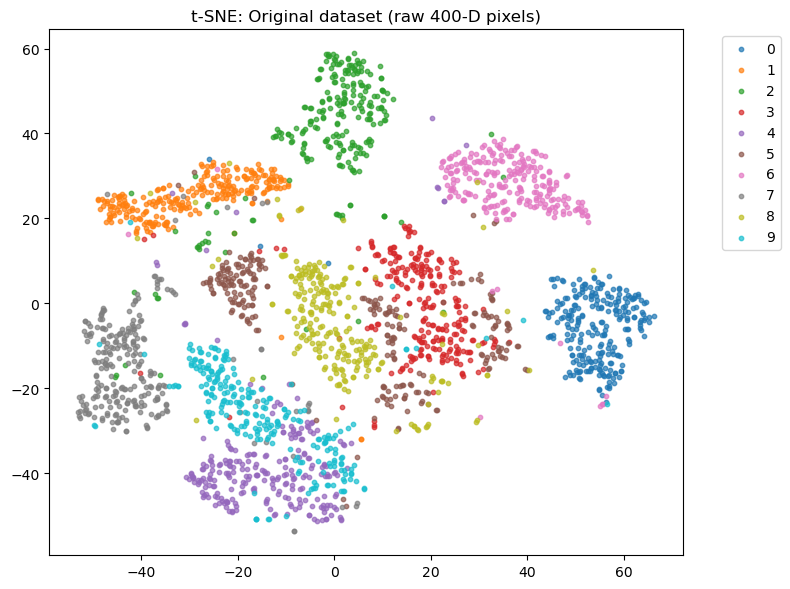

In [15]:
x_raw = train #2500,400
y_raw = train_labels.squeeze() #2500x1
z_raw = TSNE(n_components=2,perplexity=30,init="pca",learning_rate="auto",random_state=0).fit_transform(x_raw)

plt.figure(figsize=(8,6))
for d in range(10):
    idx = (y_raw == d)
    plt.scatter(z_raw[idx,0], z_raw[idx,1], s=10, alpha=0.7, label=str(d))
plt.title("t-SNE: Original dataset (raw 400-D pixels)")
plt.legend(bbox_to_anchor=(1.05,1), loc="upper left")
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import torch

model.eval() #-> NeuralNetwork (self)

A0_list, A1_list, A2_list, y_list = [], [], [], []

with torch.no_grad():
    '''torch.no_grad() Context-manager that disables gradient calculation. 
    Disabling gradient calculation is useful for inference, when you are sure that you will not call Tensor.backward(). 
    It will reduce memory consumption for computations that would otherwise have requires_grad=True.'''
    for X, y in train_loader:
        X = X.to(device)

        x = model.flatten(X)                 #(B, 400)
        z0 = model.linear_relu_stack[0](x)   #Linear 400->64
        a0 = model.linear_relu_stack[1](z0)  #ReLU  (Layer 0 activations)
        z1 = model.linear_relu_stack[2](a0)  #Linear 64->64
        a1 = model.linear_relu_stack[3](z1)  # ReLU  (Layer 1 activation application)

        a2 = model.linear_relu_stack[4](a1)  #Linear 64->10 logits (Output layer - z)

        A0_list.append(a0.cpu().numpy())
        A1_list.append(a1.cpu().numpy())
        A2_list.append(a2.cpu().numpy())
        y_list.append(y.numpy())

A0 = np.vstack(A0_list)   #(N, 64)
A1 = np.vstack(A1_list)   #(N, 64)
A2 = np.vstack(A2_list)   #(N, 10)
y_train = np.concatenate(y_list)

print(A0.shape, A1.shape, A2.shape, y_train.shape)


[[  0.        65.09612    0.       ... 127.3849    12.717102   0.      ]
 [  0.        90.764465   0.       ... 138.06177    0.         0.      ]
 [  0.         0.         0.       ...  62.121643   0.         0.      ]
 ...
 [  0.         0.         5.855633 ...  60.829414   5.33309    0.      ]
 [  0.        52.327587   0.       ...  44.860237   0.         0.      ]
 [  0.        17.259754  68.855255 ...  34.899914  35.954376   0.      ]]
(2500, 64) (2500, 64) (2500, 10) (2500,)


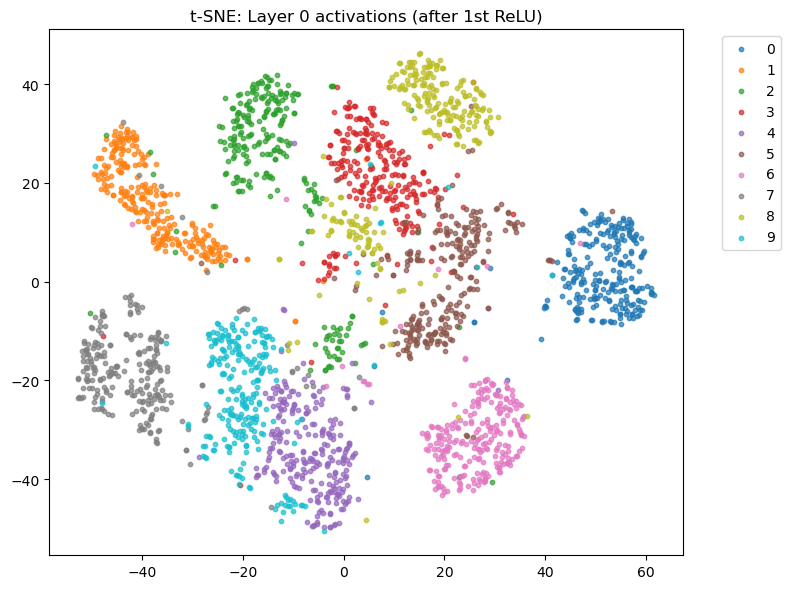

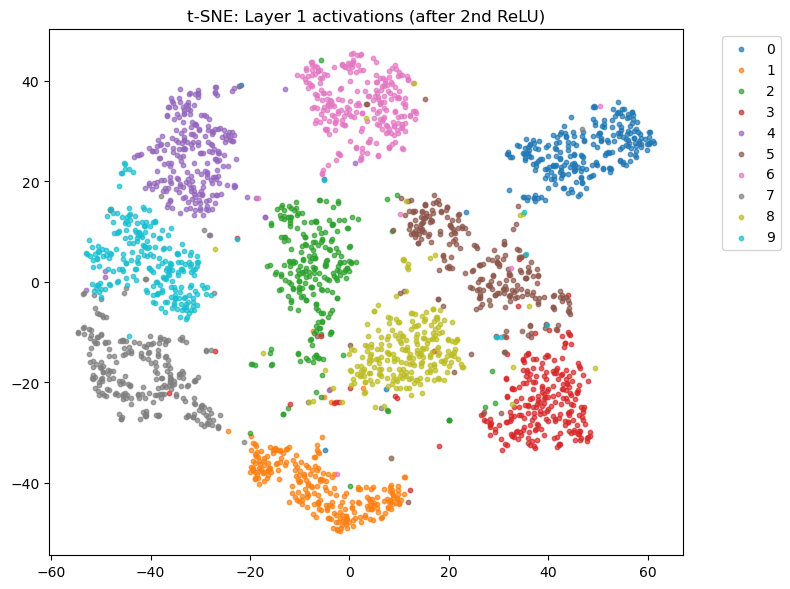

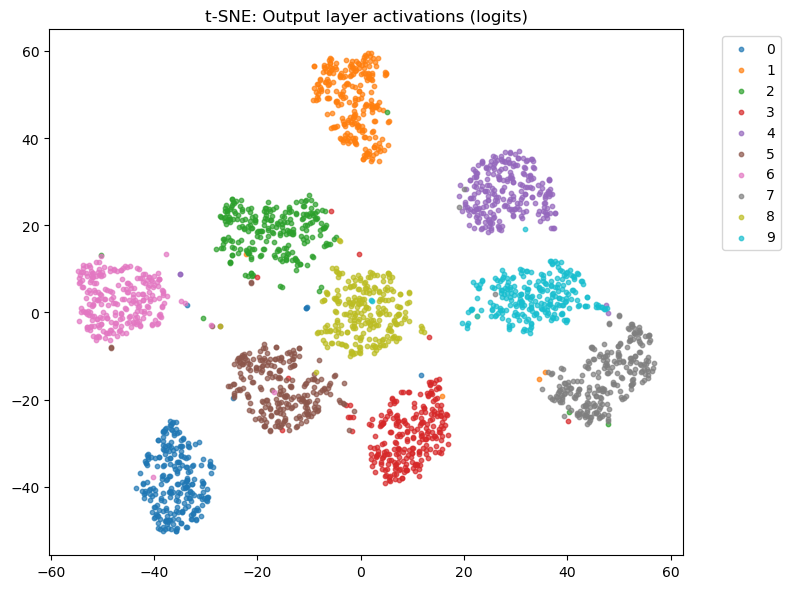

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

def tsne_plot(X, y, title,perplexity=30,seed=0):
    Z = TSNE(n_components=2, perplexity=perplexity, init="pca", learning_rate="auto", random_state=seed).fit_transform(X)
    plt.figure(figsize=(8,6))
    for d in range(10):
        idx = (y == d)
        plt.scatter(Z[idx,0], Z[idx,1], s=10, alpha=0.7, label=str(d))
    plt.title(title)
    plt.legend(bbox_to_anchor=(1.05,1), loc="upper left")
    plt.tight_layout()
    plt.show()

#1) first (0-th) layer activations
tsne_plot(A0, y_train, "t-SNE: Layer 0 activations (after 1st ReLU)")
#2) second layer activations
tsne_plot(A1, y_train, "t-SNE: Layer 1 activations (after 2nd ReLU)")
#3) third (output) layer activations
tsne_plot(A2, y_train, "t-SNE: Output layer activations (logits)")


-In the raw t‑SNE plot, most of the digit classes blend into each other, which makes sense b/c pixel space doesn’t separate them cleanly at all.
-After the first hidden layer, you can start to see some structure. The digits form loose groups, though there’s still plenty of mixing.
-By the second hidden layer, the clusters become much tighter and more distinct. This is where the network seems to learn the most meaningful features.
-At the output layer, the activations fall into very compact groups that line up with the final class predictions, showing how the model is carving out its decision boundaries.
